# FNCE 449 Day 4: Machine Learning Part A -- Logistic Regression

## Background

What is the main idea?

1. Suppose we are trying to predict a binary outcome: 
    1. a bank loan is "good" (unlikely to default) or "bad" (likely to default). 
    2. a credit card transaction is fraudulent or not;
    3. an e-mail belongs to the junk folder or not.
2. We can "code up" the binary variable by assigning values 0 and 1 to correspond to the "good" or "bad" outcome.
3. We are using a number of variables (features) $X_j$ to predict the outcome.

The logistic regression assumes that the probability of a positive outcome is $Q$, where:
$$ Q =\frac{1}{1+e^{-Y}} \in \left(0,1\right), $$
and $Y$ is a **linear** function of the predictor variables $X_j$:
$$ Y=a+b_1 X_1+b_2 X_2+\dots+b_m X_m $$

<img src="https://github.com/mariuszoican/mgt443/raw/main/Data/logistic_reg.jpeg" width="700px">

The probability of a positive outcome is therefore:
$$ Q =\frac{1}{1+e^{-a-b_1 X_1-b_2 X_2\dots-b_m X_m}} $$

Our job is to choose $a$, $b_1$, $\dots$, $b_m$ such that we maximize the "fit to the data":
1. Good outcomes in the data have **high** predicted probabilities Q;
2. Bad outcomes in the data have **low** predicted probabilities Q

In practice, we want to maximize:
$$\sum_{\text{good outcomes}} \ln \left(Q\right) + \sum_{\text{bad outcomes}} \ln \left(1-Q\right)$$

## Application to Lending Club data

**Lending Club** is a peer-to-peer FinTech platform that allows investors to lend directly to borrowers (no intermediaries). 

We want to estimate the probability of a good loan (i.e., not defaulting) using four features:
1. Home ownership (1=yes, 0=no)
2. Annual income (\$)
3. Debt to income ratio (%)
4. Credit score (FICO)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

We take a quick look at a "training" dataset:

In [2]:
path_trainlc='https://github.com/mariuszoican/mgt443/raw/main/Data/lendingclub_traindata.xlsx?raw=true'
lc_data_train=pd.read_excel(path_trainlc)
lc_data_train.head()

,home_ownership,income,dti,fico_low,loan_status
0,1,44.304,18.47,690,0
1,0,38.500,33.73,660,0
2,1,54.000,19.00,660,0
3,1,60.000,33.98,695,0
4,0,39.354,10.85,685,0


In [3]:
lc_data_train.groupby('loan_status').count()

,home_ownership,income,dti,fico_low
loan_status,,,,
0,1499,1499,1499,1499
1,7196,7196,7196,7196


In the training data, we have 8695 loans:
1. 1499 "bad" loans that defaulted
2. 7196 good loans that came through

In [4]:
lc_data_train.groupby('loan_status').count()/len(lc_data_train)

,home_ownership,income,dti,fico_low
loan_status,,,,
0,0.172398,0.172398,0.172398,0.172398
1,0.827602,0.827602,0.827602,0.827602


We first separate the $X$ variables (predictors/features) by dropping the loan status:

In [5]:
lc_data_train

,home_ownership,income,dti,fico_low,loan_status
0,1,44.304,18.47,690,0
1,0,38.500,33.73,660,0
2,1,54.000,19.00,660,0
3,1,60.000,33.98,695,0
4,0,39.354,10.85,685,0
...,...,...,...,...,...
8690,0,53.000,36.16,685,1
8691,1,113.500,11.18,690,1
8692,0,118.000,1.85,785,1
8693,1,82.000,10.90,705,1


In [6]:
X_train = lc_data_train.drop('loan_status',axis=1)
X_train.head()

,home_ownership,income,dti,fico_low
0,1,44.304,18.47,690
1,0,38.500,33.73,660
2,1,54.000,19.00,660
3,1,60.000,33.98,695
4,0,39.354,10.85,685


Then, we define the $y$ variable (binary outcome) -- in our case, the loan status:

In [7]:
y_train = lc_data_train['loan_status']
y_train.head()

0    0
1    0
2    0
3    0
4    0
Name: loan_status, dtype: int64

Now, we can estimate the logistic regression model (parameters $a$, $b_1$, $b_2$, ...).

We use the **sklearn** machine learning library:

In [8]:
from sklearn.linear_model import LogisticRegression

# create an instance of logistic regression
lgstc_reg =  LogisticRegression(solver='newton-cg')    

# fit training data on logistic regression 
lgstc_reg.fit(X_train, y_train)

# print coefficients
print(lgstc_reg.intercept_, lgstc_reg.coef_)         

[-6.38176038] [[ 0.14008696  0.00410849 -0.00114064  0.01098563]]


In [ ]:
1/(1+np.exp(-lgstc_reg.intercept_))

array([0.00177146])

<br>
The intercept is estimated as -6.56517476. 
The coefficients of the logistic regression are:

1. 0.13949599 for home_ownership (home ownership **increases** likelihood of a successful loan)
2. 0.0041 for income (higher income **increases** likelihood of a successful loan)
3. -0.00112 for debt to income (higher debt-to-income **decreases** likelihood of a successful loan)
4. and 0.01125202 for FICO score (higher FICO score **increases** likelihood of a successful loan)


These are the weights (parameters) that maximizes the likelihood of producing our given data and hence gives us the least error in predicting our response variable.

## Model evaluation: test data

To see how the model performs in the real world, we will try to predict the quality of the loans from an on an (unseen) test data.

Let us set a threshold, $Z$, for the value of $Q$ so that: 
1. If $Q\geq Z$ the loan is predicted to be good; 
2. If $Q<Z$ the loan is predicted to be bad;  

The results when a particular value of $Z$ is applied to the test set can be summarized by what is referred to as a confusion matrix:

|   	|Predict positive (no default) | Predict negative (default)   	|
|---	|---	|---	|
| **Outcome positive (no default)**   	|   True positive (TP)	|  False negative (FN)   	|
|  **Outcome negative (default)**	|   False positive (FP)	|  True negative (TN)  	|

From the confusion matrix, we can define a number of evaluation metrics for the model: 
1. **Accuracy** (percentage of observations classified correctly): $$\frac{TP+TN}{TP+FN+FP+TN}$$
2. **True positive rate** (sensitivity or recall; percentage of positive outcomes correctly predicted): $$\frac{TP}{TP+FN}$$
3. **True negative rate** (specificity; percentage of negative outcomes that were predicted as negative): $$\frac{TN}{TN+FP}$$
4. **False positive rate** (proportion of negative outcomes classified incorrectly): $$\frac{FP}{TN+FP}$$
5. **Precision** (proportion of positive predictions that prove to be correct): $$\frac{TP}{TP+FP}$$
6. **F-score** (focuses on how well positives have been identified): $$2\times\frac{\text{Precision} \times \text{TPR}}{\text{Precision} + \text{TPR}}$$

Let us now load the test data:

In [ ]:
path_testlc='https://github.com/mariuszoican/mgt443/blob/main/Data/lendingclub_testdata.xlsx?raw=true'
lc_data_test=pd.read_excel(path_testlc)
lc_data_test.head()

,home_ownership,income,dti,fico_low,loan_status
0,1,127.0,10.94,675,0
1,1,197.0,15.64,710,0
2,1,25.5,28.75,670,0
3,1,80.0,20.16,660,0
4,0,57.0,30.60,675,0


In [ ]:
len(lc_data_test)

5916

As before, we separate outcome from predictor (feature) variables:

In [ ]:
X_test = lc_data_test.drop('loan_status', axis=1)
y_test = lc_data_test['loan_status']

In [ ]:
# predict default loans based on test data set
y_pred = lgstc_reg.predict(X_test)      
# how many loans are predicted as good?
y_pred.sum(), len(y_pred)

(np.int64(5916), 5916)

In [ ]:
y_pred

array([1, 1, 1, ..., 1, 1, 1], shape=(5916,))

By default, $Z=0.5$. The model predicts that all 5916 loans in the test set are good! 

Clearly, this seems a very strong conclusion -- the model doesn't seem to work too well. 

We should look at a few other values for the threshold $Z$.

In [ ]:
from sklearn.metrics import (confusion_matrix, accuracy_score, 
recall_score, precision_score, f1_score)

In [ ]:
lgstc_reg.predict_proba(X_test)[:,1]

array([0.84344363, 0.91280504, 0.76711012, ..., 0.75642133, 0.82684527,
       0.73975619], shape=(5916,))

In [ ]:
np.median(lgstc_reg.predict_proba(X_test)[:,1])

np.float64(0.8223654818983702)

In [ ]:
lgstc_reg.predict_proba(X_test)[:,1]

array([0.84344363, 0.91280504, 0.76711012, ..., 0.75642133, 0.82684527,
       0.73975619], shape=(5916,))

<Axes: ylabel='Count'>

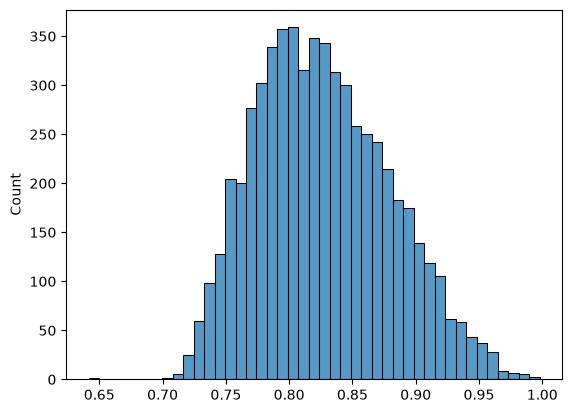

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(data=lgstc_reg.predict_proba(X_test)[:,1])

In [ ]:
Z=0.85
preds=np.where(lgstc_reg.predict_proba(X_test)[:,1]>Z,1,0)
preds

array([0, 1, 0, ..., 0, 0, 0], shape=(5916,))

In [ ]:
cm = (confusion_matrix(y_test, preds,labels=[1, 0], sample_weight=None) / 5916 )*100  
cm

array([[28.38066261, 53.73563218],
       [ 3.70182556, 14.18187965]])

|   	|Predict positive (no default) | Predict negative (default)   	|
|---	|---	|---	|
| **Outcome positive (no default)**   	|   True positive (TP)	|  False negative (FN)   	|
|  **Outcome negative (default)**	|   False positive (FP)	|  True negative (TN)  	|

In [ ]:
Z=0.85
preds=np.where(lgstc_reg.predict_proba(X_test)[:,1]>Z,1,0)
cm = confusion_matrix(y_test, preds,labels=[1, 0], sample_weight=None)
cm

array([[1679, 3179],
       [ 219,  839]])

In [ ]:
Z=0.7
preds=np.where(lgstc_reg.predict_proba(X_test)[:,1]>Z,1,0)
cm = confusion_matrix(y_test, preds,labels=[1, 0], sample_weight=None)
cm

array([[4857,    1],
       [1058,    0]])

In [ ]:
# potential values for Z (threshold probability)
Z_values = [0, .75, .80, .85,1]

#  DataFrame to store model evaluation metrics
results = pd.DataFrame(columns=["THRESHOLD", "accuracy", "recall", "tnr", 
                             'tpr', "fpr", "precision", "f1_score"]) 

# threshold column
results['THRESHOLD'] = Z_values                                                                          
             
j = 0     

# iterate over each threshold    
for i in Z_values:                                                                                       
    
     # fit data to model
    lgstc_reg.fit(X_train, y_train)   
    
    # if prob > threshold, predict 1
    preds = np.where(lgstc_reg.predict_proba(X_test)[:,1] > i, 1, 0)                                       
    
    # confusion matrix (in percentage)
    cm = (confusion_matrix(y_test, preds,labels=[1, 0], sample_weight=None) / 5916 )*100                   
    
    print('Confusion matrix for threshold =',i)
    print(cm)
    print(' ')      
    
    # True Positives
    TP = cm[0][0]   
    # False Negatives
    FN = cm[0][1]    
    # False Positives
    FP = cm[1][0]    
    # True Negatives
    TN = cm[1][1]                                                                                       
    
    results.iloc[j,1] = accuracy_score(y_test, preds) 
    results.iloc[j,2] = recall_score(y_test, preds)
    results.iloc[j,3] = TN/(FP+TN) 
    results.iloc[j,4] = TP/(FN+TP) 
    results.iloc[j,5] = FP/(FP+TN)                                                                         
    results.iloc[j,6] = precision_score(y_test, preds)
    results.iloc[j,7] = f1_score(y_test, preds)
   
   
    j += 1
    

Confusion matrix for threshold = 0
[[82.11629479  0.        ]
 [17.88370521  0.        ]]
 
Confusion matrix for threshold = 0.75
[[77.9749831   4.1413117 ]
 [16.32860041  1.5551048 ]]
 
Confusion matrix for threshold = 0.8
[[55.67951318 26.43678161]
 [ 9.83772819  8.04597701]]
 
Confusion matrix for threshold = 0.85
[[28.38066261 53.73563218]
 [ 3.70182556 14.18187965]]
 
Confusion matrix for threshold = 1
[[ 0.         82.11629479]
 [ 0.         17.88370521]]
 


|   Z=0.75	|Predict positive (no default) | Predict negative (default)   	|
|---	|---	|---	|
| **Outcome positive (no default)**   	|   77.58	|  4.53   	|
|  **Outcome negative (default)**	|   16.26	|  1.62 	|

|   Z=0.80	|Predict positive (no default) | Predict negative (default)   	|
|---	|---	|---	|
| **Outcome positive (no default)**   	|   55.29	|  26.82   	|
|  **Outcome negative (default)**	|   9.73	|  8.14 	|

|   Z=0.85	|Predict positive (no default) | Predict negative (default)   	|
|---	|---	|---	|
| **Outcome positive (no default)**   	|   28.65	|  53.46   	|
|  **Outcome negative (default)**	|   3.73	|  14.14 	|

As we increase $Z$, we predict more negative outcomes (finding a predicted probability $\leq Z$ is more likely). 

Numbers in the right-side column increase, and numbers in the left-side column decrease.

Let's look at model evaluation metrics:

In [ ]:
print('ALL METRICS')
print( results.T)

ALL METRICS
                  0         1         2         3         4
THRESHOLD       0.0      0.75       0.8      0.85       1.0
accuracy   0.821163  0.795301  0.637255  0.425625  0.178837
recall          1.0  0.949568  0.678057  0.345615       0.0
tnr             0.0  0.086957  0.449905  0.793006       1.0
tpr             1.0  0.949568  0.678057  0.345615       0.0
fpr             1.0  0.913043  0.550095  0.206994       0.0
precision  0.821163  0.826851  0.849845  0.884615       0.0
f1_score   0.901801   0.88397  0.754294   0.49704       0.0


If we set $Z=0$, we always predict no default. The accuracy is 82%, since that is the proportion loans in the test sample end up being successful. However, the model does not tell us much (indeed, it doesn't use the data at all). It must be that maximizing accuracy is not the winning modeling strategy!

Note the trade-off between the **true positive rate** (TPR) and the **false positive rate** (FPR):
1. When $Z=0$, both are 100% (all loans are successful);
2. When $Z=1$, both are 0% (no successful loan is detected).

This means that we can identify a greater proportion of the good loans only if we also misclassify a greater proportion of the bad loans. 

To assess the predictive power of a model, we plot the **receiver operating curve (ROC)** (TPR against FPR). The area under this curve (**AUC**) is a measure of predictive power: 
1. If $AUC=1$, the model is perfect: you can commbine a 100% true positive rate with 0% false positive rate.
2. An $AUC=0.5$ (i.e., the $ROC$ is just a diagonal line) corresponds to no predictive power -- essentially the predictions are random.

How to plot the **ROC** and compute the **AUC**?

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
lr_prob=lgstc_reg.predict_proba(X_test)
lr_prob=lr_prob[:, 1]

lr_auc=roc_auc_score(y_test,lr_prob) 
lr_auc
#lr_fpr,lr_tpr,_=roc_curve(y_test,lr_prob) # ROC curve for predictive model

0.6019314310929451

In [ ]:
lr_fpr,lr_tpr,_=roc_curve(y_test,lr_prob)

In [ ]:
lr_tpr # y-axis in ROC

array([0.        , 0.        , 0.        , ..., 0.99897077, 0.99897077,
       1.        ], shape=(1687,))

In [ ]:
lr_fpr # x-axis in ROC

array([0.00000000e+00, 9.45179584e-04, 1.89035917e-03, ...,
       9.99054820e-01, 1.00000000e+00, 1.00000000e+00], shape=(1687,))

AUC for predictive model:  0.6019314310929451
AUC for random model:  0.5
AUC for perfect model:  1.0


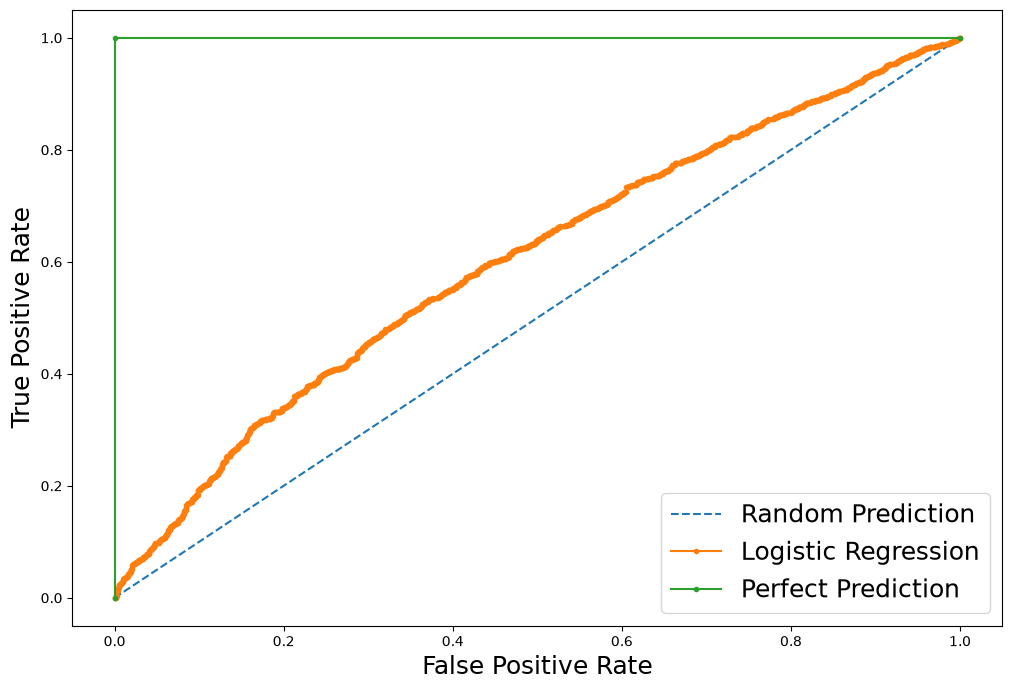

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score


## PREDICTED SUCCESS PROBABILITIES
lr_prob=lgstc_reg.predict_proba(X_test) # return probability of outcome "0", respectively outcome "1"
lr_prob=lr_prob[:, 1] # keep only the probability of outcome 1

# compute AUC score for predictive model
lr_auc=roc_auc_score(y_test,lr_prob) 
lr_fpr,lr_tpr,_=roc_curve(y_test,lr_prob) # ROC curve for predictive model


## An uninformative model: always predict default 

ns_prob=[0 for _ in range(len(y_test))] # a "dummy" model: predict outcome 0 (default), regardless.
ns_auc=roc_auc_score(y_test,ns_prob) # compute AUC score for random model
ns_fpr,ns_tpr,_=roc_curve(y_test,ns_prob) # ROC curve for random model

## A perfect model: predict default only when it has happened (hindsight!)

hind_prob=y_test
hind_auc=roc_auc_score(y_test,hind_prob)
hind_fpr,hind_tpr,_=roc_curve(y_test,hind_prob) # ROC curve for random model

print("AUC for predictive model: ",lr_auc)
print("AUC for random model: ",ns_auc)
print("AUC for perfect model: ",hind_auc)


plt.figure(figsize=(12,8))

plt.plot(ns_fpr,ns_tpr,linestyle='--',label='Random Prediction')
plt.plot(lr_fpr,lr_tpr,marker='.',label='Logistic Regression')
plt.plot(hind_fpr,hind_tpr,marker='.',label='Perfect Prediction')

plt.xlabel('False Positive Rate',fontsize=18)
plt.ylabel('True Positive Rate',fontsize=18)
plt.legend(fontsize=18)
plt.show()

The **ROC** and **AUC** give you a feeling on how good the predictive power of the model is (i.e., of the $X$ variables included), but don't tell you where to stand on the trade-off between true and false positives.

Let $c\geq 1$ be the relative cost of a default. Then, as a lender you want to maximize:
$$ \max_{Z} \text{TruePositive}\left(Z\right)-c\times\text{FalsePositive}\left(Z\right)$$

In [ ]:
def lender_problem(Z,c):
    # if prob > threshold, predict 1
    preds = np.where(lgstc_reg.predict_proba(X_test)[:,1] > Z, 1, 0)                                       
    
    # confusion matrix (in percentage)
    cm = (confusion_matrix(y_test, preds,labels=[1, 0], sample_weight=None) / 5916 )*100                   
    
    # True Positives
    TP = cm[0][0]   
    # False Positives
    FP = cm[1][0]    
                                                                                  
    return TP-c*FP

In [ ]:
import scipy.optimize as spo
c=3

# brute force finding of starting value
z_space=np.linspace(0,1,100)
z_brute_force=z_space[np.argmax([lender_problem(zi,c) for zi in z_space])]
#use the brute force solution to narrow down
spo.fmin(lambda x: -lender_problem(x,c), z_brute_force, ftol=10**-4)

Optimization terminated successfully.
         Current function value: -29.107505
         Iterations: 11
         Function evaluations: 24


array([0.73679766])

In this setting, with $c=4$, the optimal $Z$ score for the lender to balance true/false positives is:
$$Z=0.81$$

In [ ]:
def opt_z(c):
    z_space=np.linspace(0,1,100)
    z_brute_force=z_space[np.argmax([lender_problem(zi,c) for zi in z_space])]
    #use the brute force solution to narrow down
    o=spo.fmin(lambda x: -lender_problem(x,c), z_brute_force, ftol=10**-4)
    return o

In [ ]:
c_space=np.linspace(0,8,10)
z_space=[opt_z(ci) for ci in c_space]

Optimization terminated successfully.
         Current function value: -82.116295
         Iterations: 3
         Function evaluations: 8
Optimization terminated successfully.
         Current function value: -66.219668
         Iterations: 3
         Function evaluations: 8
Optimization terminated successfully.
         Current function value: -50.323041
         Iterations: 3
         Function evaluations: 8
Optimization terminated successfully.
         Current function value: -34.820825
         Iterations: 10
         Function evaluations: 24
Optimization terminated successfully.
         Current function value: -21.596800
         Iterations: 13
         Function evaluations: 29
Optimization terminated successfully.
         Current function value: -14.067313
         Iterations: 11
         Function evaluations: 25
Optimization terminated successfully.
         Current function value: -9.499662
         Iterations: 13
         Function evaluations: 31
Optimization terminated suc

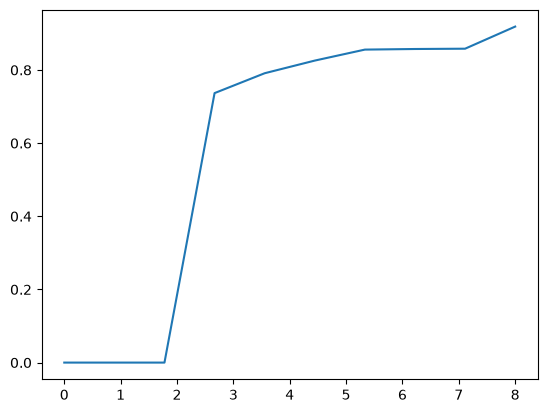

In [ ]:
plt.plot(c_space,z_space)

In [ ]:
lr_prob.min()

np.float64(0.6416325363579375)